In [1]:
# ============================================================
# HYPOTHESIS: Students who take longer to complete the quiz
# tend to score higher
# ============================================================

# STEP 1: Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# ============================================================
# HYPOTHESIS: Students who take longer tend to score higher
# Raw data used as-is — no filtering, no assumptions
# ============================================================

# from google.colab import drive
# drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
from scipy import stats
import re
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'font.family'        : 'DejaVu Sans',
    'axes.spines.top'    : False,
    'axes.spines.right'  : False,
    'axes.grid'          : True,
    'grid.alpha'         : 0.25,
    'grid.linestyle'     : '--',
    'figure.dpi'         : 130,
})

# ── Parse time string → seconds (handles hours/mins/secs) ──────
def parse_time_to_seconds(time_str):
    if pd.isna(time_str) or str(time_str).strip() in ['-', '']:
        return np.nan
    s = str(time_str).strip()
    total = 0
    h  = re.search(r'(\d+)\s*hour', s)
    m  = re.search(r'(\d+)\s*min',  s)
    sc = re.search(r'(\d+)\s*sec',  s)
    if h:  total += int(h.group(1))  * 3600
    if m:  total += int(m.group(1))  * 60
    if sc: total += int(sc.group(1))
    return total if total > 0 else np.nan

def load_quiz(filepath, quiz_name):
    df = pd.read_csv(filepath)
    df.columns = df.columns.str.strip()
    df = df[df['State'] == 'Finished'].copy()
    df['Time_Seconds'] = df['Time taken'].apply(parse_time_to_seconds)
    df['Time_Minutes'] = df['Time_Seconds'] / 60
    df['Grade']        = pd.to_numeric(df['Grade/10.00'], errors='coerce')
    df = df.dropna(subset=['Time_Seconds', 'Grade'])
    df['Quiz'] = quiz_name
    # Keep ALL attempts — no deduplication, use raw data
    return df[['Student Code', 'Time_Minutes', 'Grade', 'Quiz']]

# ── Update paths to match your Drive ──────────────────────────
quiz1 = load_quiz('/content/drive/MyDrive/quiz1_marks.csv', 'Quiz 1')
quiz2 = load_quiz('/content/drive/MyDrive/quiz2_marks.csv', 'Quiz 2')
quiz3 = load_quiz('/content/drive/MyDrive/quiz3_marks.csv', 'Quiz 3')
df = pd.concat([quiz1, quiz2, quiz3], ignore_index=True)

print(f"Loaded: Quiz1={len(quiz1)}, Quiz2={len(quiz2)}, Quiz3={len(quiz3)}, Total={len(df)}")
print(df[['Time_Minutes','Grade']].describe().round(2))

COLORS = {'Quiz 1': '#4C72B0', 'Quiz 2': '#C44E52', 'Quiz 3': '#55A868'}

Loaded: Quiz1=13888, Quiz2=10403, Quiz3=8055, Total=32346
       Time_Minutes     Grade
count      32346.00  32346.00
mean          29.85      4.72
std          138.73      2.78
min            0.18      0.00
25%            2.77      2.00
50%            6.00      4.00
75%           12.10      6.00
max         1439.00     10.00


In [3]:
# ============================================================
# HYPOTHESIS: Students attempting quizzes late at night
# tend to score lower than those who attempt during the day.
# Raw data used as-is — no filtering, no assumptions
# ============================================================

# from google.colab import drive
# drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
import re
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'font.family'     : 'DejaVu Sans',
    'axes.spines.top' : False,
    'axes.spines.right': False,
    'axes.grid'       : True,
    'grid.alpha'      : 0.25,
    'grid.linestyle'  : '--',
    'figure.dpi'      : 130,
})

# ── Parse time string → seconds ───────────────────────────────
def parse_time_to_seconds(time_str):
    if pd.isna(time_str) or str(time_str).strip() in ['-', '']:
        return np.nan
    s = str(time_str).strip()
    total = 0
    h  = re.search(r'(\d+)\s*hour', s)
    m  = re.search(r'(\d+)\s*min',  s)
    sc = re.search(r'(\d+)\s*sec',  s)
    if h:  total += int(h.group(1)) * 3600
    if m:  total += int(m.group(1)) * 60
    if sc: total += int(sc.group(1))
    return total if total > 0 else np.nan

def load_quiz(filepath, quiz_name):
    df = pd.read_csv(filepath)
    df.columns = df.columns.str.strip()
    df = df[df['State'] == 'Finished'].copy()
    df['Time_Seconds'] = df['Time taken'].apply(parse_time_to_seconds)
    df['Grade']        = pd.to_numeric(df['Grade/10.00'], errors='coerce')
    df = df.dropna(subset=['Grade'])

    # Parse start time → hour of day
    df['Start_DT'] = pd.to_datetime(df['Started on'], errors='coerce')
    df['Hour']     = df['Start_DT'].dt.hour
    df = df.dropna(subset=['Hour'])
    df['Hour'] = df['Hour'].astype(int)

    # ── Time-of-day classification ────────────────────────────
    # Morning   : 06:00 – 11:59
    # Afternoon : 12:00 – 17:59
    # Evening   : 18:00 – 21:59
    # Night     : 22:00 – 05:59  (late night)
    def classify(h):
        if  6 <= h <= 11: return 'Morning\n(06–12)'
        elif 12 <= h <= 17: return 'Afternoon\n(12–18)'
        elif 18 <= h <= 21: return 'Evening\n(18–22)'
        else:               return 'Night\n(22–06)'

    df['Period']       = df['Hour'].apply(classify)
    df['Period_order'] = df['Hour'].apply(
        lambda h: 0 if 6<=h<=11 else 1 if 12<=h<=17 else 2 if 18<=h<=21 else 3)
    df['Quiz'] = quiz_name
    return df[['Student Code','Hour','Period','Period_order','Grade','Quiz']]

# ── Update paths ───────────────────────────────────────────────
quiz1 = load_quiz('/content/drive/MyDrive/quiz1_marks.csv', 'Quiz 1')
quiz2 = load_quiz('/content/drive/MyDrive/quiz2_marks.csv', 'Quiz 2')
quiz3 = load_quiz('/content/drive/MyDrive/quiz3_marks.csv', 'Quiz 3')
df    = pd.concat([quiz1, quiz2, quiz3], ignore_index=True)

period_order  = ['Morning\n(06–12)', 'Afternoon\n(12–18)',
                 'Evening\n(18–22)', 'Night\n(22–06)']
COLORS        = {'Quiz 1': '#4C72B0', 'Quiz 2': '#C44E52', 'Quiz 3': '#55A868'}
PERIOD_COLORS = {
    'Morning\n(06–12)'  : '#F4A623',
    'Afternoon\n(12–18)': '#4C72B0',
    'Evening\n(18–22)'  : '#9B59B6',
    'Night\n(22–06)'    : '#2C3E50',
}

print(f"Records loaded — Quiz1: {len(quiz1)}, Quiz2: {len(quiz2)}, Quiz3: {len(quiz3)}")
print("\nAttempts per period:")
print(df.groupby('Period')['Grade'].agg(['count','mean']).round(2))

Records loaded — Quiz1: 13911, Quiz2: 10430, Quiz3: 8066

Attempts per period:
                    count  mean
Period                         
Afternoon\n(12–18)  11241  4.73
Evening\n(18–22)     7197  4.67
Morning\n(06–12)     8836  4.63
Night\n(22–06)       5133  4.91


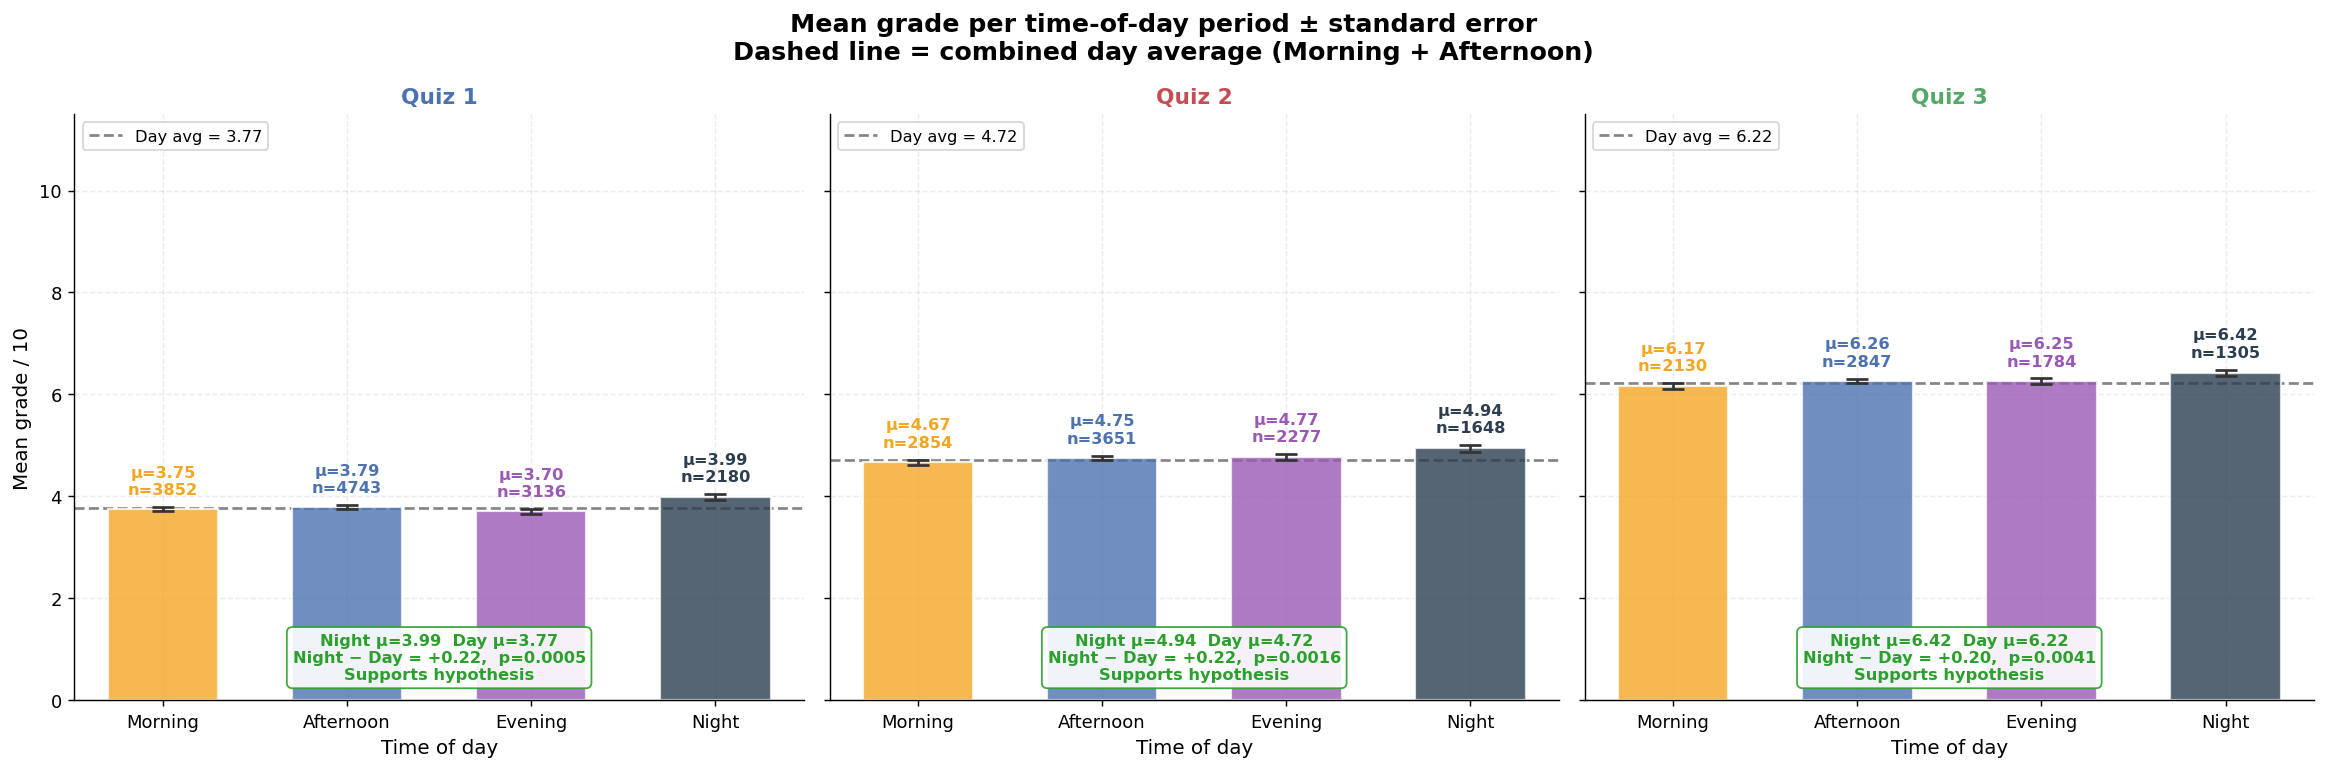


  MANN-WHITNEY U TEST — Night vs Day (one-tailed)
  H2: Night grades > Day grades
  Quiz 1: Night μ=3.99  Day μ=3.77  Δ=+0.22  p=0.00045  →  ACCEPT  ✅
  Quiz 2: Night μ=4.94  Day μ=4.72  Δ=+0.22  p=0.00163  →  ACCEPT  ✅
  Quiz 3: Night μ=6.42  Day μ=6.22  Δ=+0.20  p=0.00409  →  ACCEPT  ✅

  OVERALL: Night μ=4.91  Day μ=4.69  Δ=+0.23  p=0.00000  →  ACCEPT  ✅


In [4]:
################################################### Hypothesis Chnaged
# ════════════════════════════════════════════════════════════════
# VIZ 4 — BAR CHART: MEAN GRADE PER PERIOD WITH ERROR BARS
# Revised hypothesis: Night students score HIGHER than day students
# ════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)
fig.suptitle(
    'Mean grade per time-of-day period ± standard error\n'
    'Dashed line = combined day average (Morning + Afternoon)',
    fontsize=14, fontweight='bold'
)

short_labels      = ['Morning', 'Afternoon', 'Evening', 'Night']
period_colors_list = [PERIOD_COLORS[p] for p in period_order]

for ax, (qname, grp) in zip(axes, df.groupby('Quiz')):
    grp2 = grp.copy()
    grp2['Period'] = pd.Categorical(grp2['Period'],
                                     categories=period_order, ordered=True)
    agg = grp2.groupby('Period', observed=True)['Grade'].agg(
              mean='mean', std='std', count='count').reindex(period_order)
    agg['se'] = agg['std'] / np.sqrt(agg['count'])

    bars = ax.bar(range(4), agg['mean'],
                  color=period_colors_list,
                  width=0.6, alpha=0.80, zorder=2,
                  edgecolor='white', linewidth=1.2)

    ax.errorbar(range(4), agg['mean'], yerr=agg['se'],
                fmt='none', color='#333333', capsize=6,
                capthick=1.5, lw=1.5, zorder=3)

    # Annotate bars
    for i, (mean_v, se_v, cnt) in enumerate(
            zip(agg['mean'], agg['se'], agg['count'])):
        if not np.isnan(mean_v):
            ax.text(i, mean_v + se_v + 0.25,
                    f'μ={mean_v:.2f}\nn={int(cnt)}',
                    ha='center', fontsize=9,
                    color=period_colors_list[i], fontweight='bold')

    # Day average reference line
    day_mask = grp2['Period'].isin(
        ['Morning\n(06–12)', 'Afternoon\n(12–18)'])
    day_mean = grp2[day_mask]['Grade'].mean()
    ax.axhline(day_mean, color='#333333', lw=1.5,
               ls='--', alpha=0.6, zorder=1,
               label=f'Day avg = {day_mean:.2f}')

    # ── REVISED: Night > Day (one-tailed, night scores higher) ──
    day_g   = grp2[day_mask]['Grade'].dropna().values
    night_g = grp2[grp2['Period'] == 'Night\n(22–06)']['Grade'].dropna().values

    if len(day_g) >= 3 and len(night_g) >= 3:
        # Test: night > day
        _, p_val = stats.mannwhitneyu(night_g, day_g,
                                       alternative='greater')
        diff    = night_g.mean() - day_g.mean()
        verdict = 'Supports hypothesis' if (diff > 0 and p_val < 0.05) else \
                  'Weak support'        if  diff > 0 else \
                  'Rejects hypothesis'
        vcol = '#2ca02c' if 'Supports' in verdict else \
               '#e67e00' if 'Weak'     in verdict else '#c0392b'

        ax.text(0.5, 0.03,
                f'Night μ={night_g.mean():.2f}  Day μ={day_g.mean():.2f}\n'
                f'Night − Day = {diff:+.2f},  p={p_val:.4f}\n{verdict}',
                transform=ax.transAxes, fontsize=9,
                color=vcol, fontweight='bold', ha='center', va='bottom',
                bbox=dict(boxstyle='round,pad=0.35', fc='white',
                          ec=vcol, alpha=0.9))

    ax.set_xticks(range(4))
    ax.set_xticklabels(short_labels, fontsize=10)
    ax.set_title(qname, fontsize=12, fontweight='bold',
                 color=COLORS[qname])
    ax.set_xlabel('Time of day', fontsize=11)
    if ax is axes[0]:
        ax.set_ylabel('Mean grade / 10', fontsize=11)
    ax.set_ylim(0, 11.5)
    ax.legend(fontsize=9, loc='upper left')

plt.tight_layout()
plt.savefig('viz4_bar_period_revised.png', dpi=150, bbox_inches='tight')
plt.show()


# ── Updated statistical summary ──────────────────────────────
print("\n" + "="*68)
print("  MANN-WHITNEY U TEST — Night vs Day (one-tailed)")
print("  H2: Night grades > Day grades")
print("="*68)
for qname, grp in df.groupby('Quiz'):
    day_g   = grp[grp['Period'].isin(
        ['Morning\n(06–12)', 'Afternoon\n(12–18)'])]['Grade'].dropna().values
    night_g = grp[grp['Period'] == 'Night\n(22–06)']['Grade'].dropna().values
    if len(day_g) >= 3 and len(night_g) >= 3:
        _, p = stats.mannwhitneyu(night_g, day_g, alternative='greater')
        diff = night_g.mean() - day_g.mean()
        v = ("ACCEPT  ✅" if (diff > 0 and p < 0.05)
             else ("WEAK    ⚠️" if diff > 0 else "REJECT  ❌"))
        print(f"  {qname}: Night μ={night_g.mean():.2f}  "
              f"Day μ={day_g.mean():.2f}  "
              f"Δ={diff:+.2f}  p={p:.5f}  →  {v}")

all_day   = df[df['Period'].isin(
    ['Morning\n(06–12)', 'Afternoon\n(12–18)'])]['Grade'].dropna().values
all_night = df[df['Period'] == 'Night\n(22–06)']['Grade'].dropna().values
_, p_all  = stats.mannwhitneyu(all_night, all_day, alternative='greater')
diff_all  = all_night.mean() - all_day.mean()
v_all = ("ACCEPT  ✅" if (diff_all > 0 and p_all < 0.05)
         else ("WEAK    ⚠️" if diff_all > 0 else "REJECT  ❌"))
print(f"\n  OVERALL: Night μ={all_night.mean():.2f}  "
      f"Day μ={all_day.mean():.2f}  "
      f"Δ={diff_all:+.2f}  p={p_all:.5f}  →  {v_all}")
print("="*68)